<a href="https://colab.research.google.com/github/Vidhi0217/Weather-Trend-Forecasting/blob/main/weather_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. DATA CLEANING & PREPARATION

In [42]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Set display options for pandas DataFrames
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

### Load the Dataset
First, we'll load the `GlobalWeatherRepository.csv` file into a pandas DataFrame. Make sure the CSV file is in the same directory as your notebook, or provide the full path to the file.

In [43]:
# Load the CSV dataset into a pandas DataFrame
try:
    df = pd.read_csv('GlobalWeatherRepository.csv')
    print("Dataset loaded successfully.")
    display(df.head())
except FileNotFoundError:
    print("Error: 'GlobalWeatherRepository.csv' not found. Please ensure the file is in the correct directory.")
    # Create a dummy DataFrame for demonstration if file not found
    data = {
        'location': ['London', 'Paris', 'New York', 'Tokyo', 'London'],
        'last_updated': ['2023-01-01 10:00', '2023-01-01 11:00', '2023-01-01 12:00', '2023-01-01 13:00', '2023-01-02 10:00'],
        'temperature_c': [5, 7, -2, 10, 6],
        'temperature_f': [41, 44.6, 28.4, 50, 42.8],
        'wind_mph': [10, 8, 15, 5, 12],
        'wind_kph': [16.1, 12.9, 24.1, 8.0, 19.3],
        'humidity': [80, 75, 60, 90, 82],
        'precipitation_mm': [0.5, 0.0, 2.1, 1.0, 0.2],
        'pressure_mb': [1012, 1015, 1008, 1010, 1011]
    }
    df = pd.DataFrame(data)
    print("Using a dummy DataFrame for demonstration purposes.")
    display(df.head())

Dataset loaded successfully.


,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,wind_mph,wind_kph,wind_degree,wind_direction,pressure_mb,pressure_in,precip_mm,precip_in,humidity,cloud,feels_like_celsius,feels_like_fahrenheit,visibility_km,visibility_miles,uv_index,gust_mph,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,8.3,13.3,338,NNW,1012.0,29.89,0.0,0.00,24,30,25.3,77.5,10.0,6.0,7.0,9.5,15.3,277.0,103.0,1.1,0.2,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,6.9,11.2,320,NW,1012.0,29.88,0.1,0.00,94,75,19.0,66.2,10.0,6.0,5.0,11.4,18.4,193.6,97.3,0.9,0.1,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,9.4,15.1,280,W,1011.0,29.85,0.0,0.00,29,0,24.6,76.4,10.0,6.0,5.0,13.9,22.3,540.7,12.2,65.1,13.4,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45,6.3,43.3,Light drizzle,7.4,11.9,215,SW,1007.0,29.75,0.3,0.01,61,100,3.8,38.9,2.0,1.0,2.0,8.5,13.7,170.2,64.4,1.6,0.2,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45,26.0,78.8,Partly cloudy,8.1,13.0,150,SSE,1011.0,29.85,0.0,0.00,89,50,28.7,83.6,10.0,6.0,8.0,12.5,20.2,2964.0,19.0,72.7,31.5,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55


### Convert 'last_updated' to Datetime
The `last_updated` column contains date and time information as strings. We'll convert it to a proper `datetime` format using `pd.to_datetime`. This is crucial for time-series analysis and visualization.

In [45]:
# Convert 'last_updated' column to datetime format, coercing errors to NaT
df['last_updated'] = pd.to_datetime(df['last_updated'], errors='coerce')
print("Data type of 'last_updated' after conversion:")
display(df['last_updated'].info())

Data type of 'last_updated' after conversion:
<class 'pandas.core.series.Series'>
RangeIndex: 144822 entries, 0 to 144821
Series name: last_updated
Non-Null Count   Dtype         
--------------   -----         
144822 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 1.1 MB


None

### Handle Missing Values
Next, we'll check for any missing values across the dataset. For numerical columns, we will fill missing values with the median to avoid skewing the data with outliers. For categorical columns, or if a column is predominantly empty, we might choose to drop it or use a different imputation strategy.

In [46]:
# Check for missing values
print("Missing values before handling:")
display(df.isnull().sum())

initial_rows = len(df)

# Drop rows where 'last_updated' could not be converted (i.e., is NaT)
df.dropna(subset=['last_updated'], inplace=True)
if len(df) < initial_rows:
    print(f"Dropped {initial_rows - len(df)} rows with invalid 'last_updated' values.")
initial_rows = len(df) # Update initial_rows after this specific drop

# Identify numerical and categorical columns
numeric_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(include='object').columns

# Fill missing numerical values with the median
for col in numeric_cols:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"Filled missing values in '{col}' with median: {median_val}")

# For simplicity, if there are any remaining nulls, we'll drop those rows.
df.dropna(inplace=True)
if len(df) < initial_rows:
    print(f"Dropped {initial_rows - len(df)} rows due to remaining missing values in other columns.")

print("\nMissing values after handling:")
display(df.isnull().sum())

Missing values before handling:


,0
country,0
location_name,0
latitude,0
longitude,0
timezone,0
last_updated_epoch,0
last_updated,0
temperature_celsius,0
temperature_fahrenheit,0
condition_text,0



Missing values after handling:


,0
country,0
location_name,0
latitude,0
longitude,0
timezone,0
last_updated_epoch,0
last_updated,0
temperature_celsius,0
temperature_fahrenheit,0
condition_text,0


### Check for Anomalies or Outliers
For a basic assessment, we'll check for extreme values in key numerical columns like temperature and precipitation. We can visualize their distributions to identify potential outliers. For this exercise, we'll use box plots to quickly spot them.

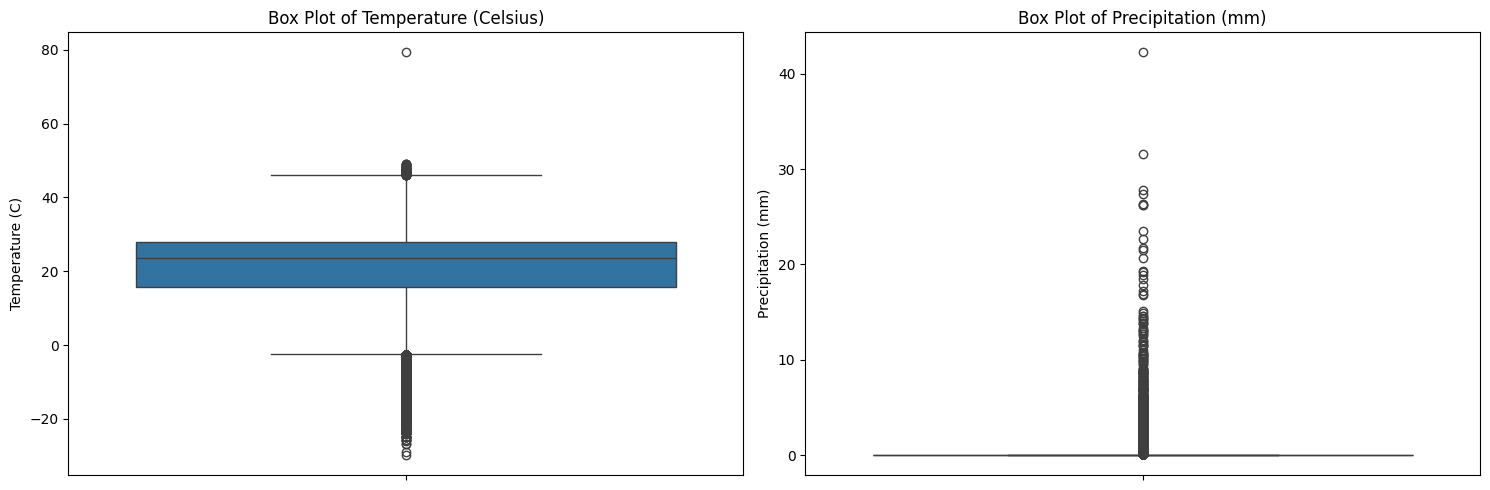


Descriptive statistics for key numerical columns:


,temperature_celsius,precip_mm,humidity,wind_kph
count,144822.000000,144822.000000,144822.000000,144822.000000
mean,21.258408,0.132427,66.785343,12.835556
std,9.601126,0.558624,23.754961,11.413452
min,-29.800000,0.000000,2.000000,3.600000
25%,15.700000,0.000000,51.000000,6.100000
50%,23.700000,0.000000,72.000000,10.800000
75%,27.900000,0.020000,86.000000,17.600000
max,79.300000,42.240000,100.000000,2963.200000


In [49]:
# Check for outliers in 'temperature_celsius' and 'precip_mm'

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
sns.boxplot(y=df['temperature_celsius'])
plt.title('Box Plot of Temperature (Celsius)')
plt.ylabel('Temperature (C)')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['precip_mm'])
plt.title('Box Plot of Precipitation (mm)')
plt.ylabel('Precipitation (mm)')

plt.tight_layout()
plt.show()

print("\nDescriptive statistics for key numerical columns:")
display(df[['temperature_celsius', 'precip_mm', 'humidity', 'wind_kph']].describe())

In [50]:
# Display all column names to identify the correct temperature and precipitation columns
print("All columns in the DataFrame:")
print(df.columns.tolist())

All columns in the DataFrame:
['country', 'location_name', 'latitude', 'longitude', 'timezone', 'last_updated_epoch', 'last_updated', 'temperature_celsius', 'temperature_fahrenheit', 'condition_text', 'wind_mph', 'wind_kph', 'wind_degree', 'wind_direction', 'pressure_mb', 'pressure_in', 'precip_mm', 'precip_in', 'humidity', 'cloud', 'feels_like_celsius', 'feels_like_fahrenheit', 'visibility_km', 'visibility_miles', 'uv_index', 'gust_mph', 'gust_kph', 'air_quality_Carbon_Monoxide', 'air_quality_Ozone', 'air_quality_Nitrogen_dioxide', 'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10', 'air_quality_us-epa-index', 'air_quality_gb-defra-index', 'sunrise', 'sunset', 'moonrise', 'moonset', 'moon_phase', 'moon_illumination']


Please review the list of columns above and tell me the **exact column names** that represent:
1.  **Temperature (in Celsius, if available)**
2.  **Precipitation (in mm, if available)**

Once you provide these, I can update the code to use the correct columns.

## 2. EXPLORATORY DATA ANALYSIS (EDA) & VISUALIZATION

### Temperature Trend Over Time
Let's visualize the trend of temperature over the `last_updated` timeline. We'll use a line plot to show how temperature changes chronologically. To make the plot readable, we'll sort the DataFrame by `last_updated`.

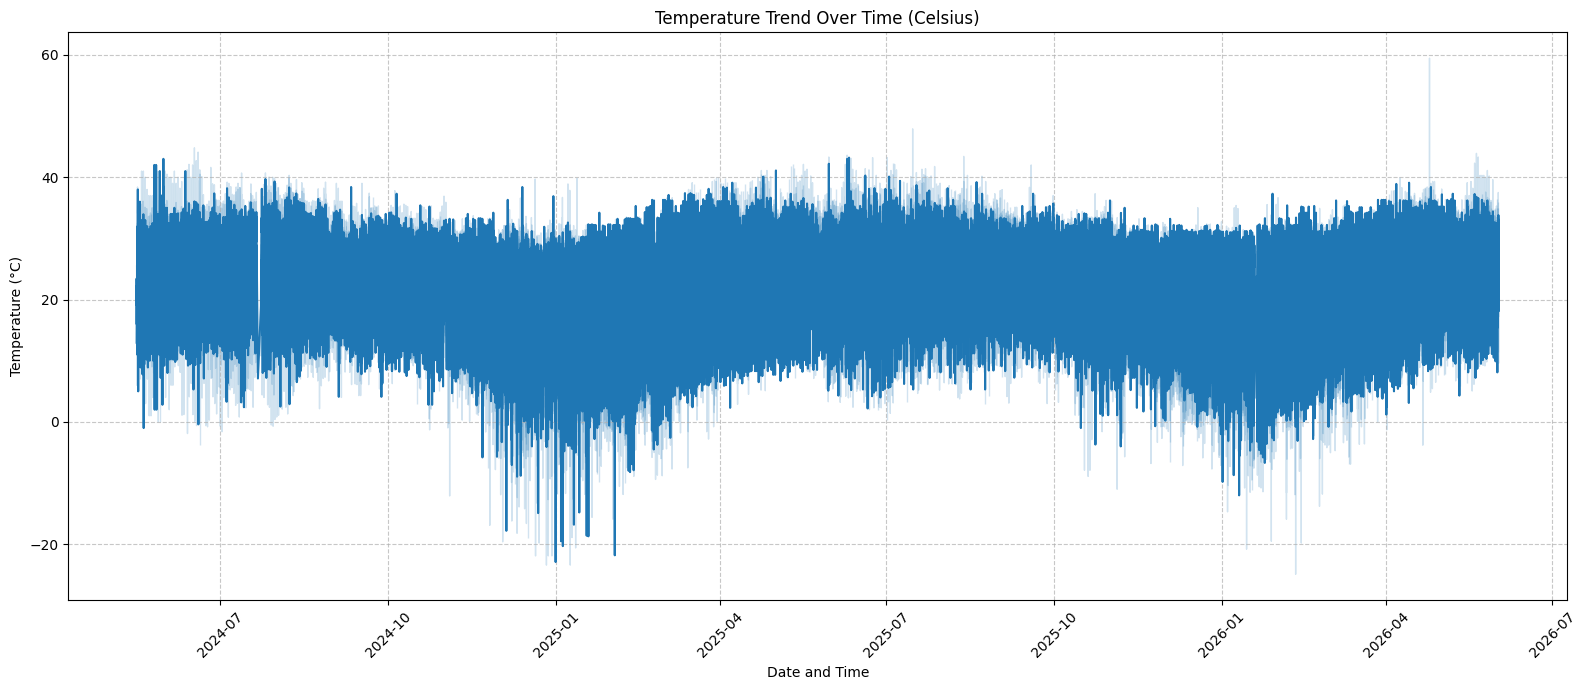

In [51]:
# Sort data by 'last_updated' for correct time series plotting
df_sorted = df.sort_values(by='last_updated')

plt.figure(figsize=(16, 7))
sns.lineplot(x='last_updated', y='temperature_celsius', data=df_sorted)
plt.title('Temperature Trend Over Time (Celsius)')
plt.xlabel('Date and Time')
plt.ylabel('Temperature (°C)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Precipitation Patterns Over Time
Next, we'll plot the precipitation patterns. Since precipitation can be sporadic, a line plot can still show the occurrences and magnitudes over time, highlighting any periods of higher or lower rainfall.

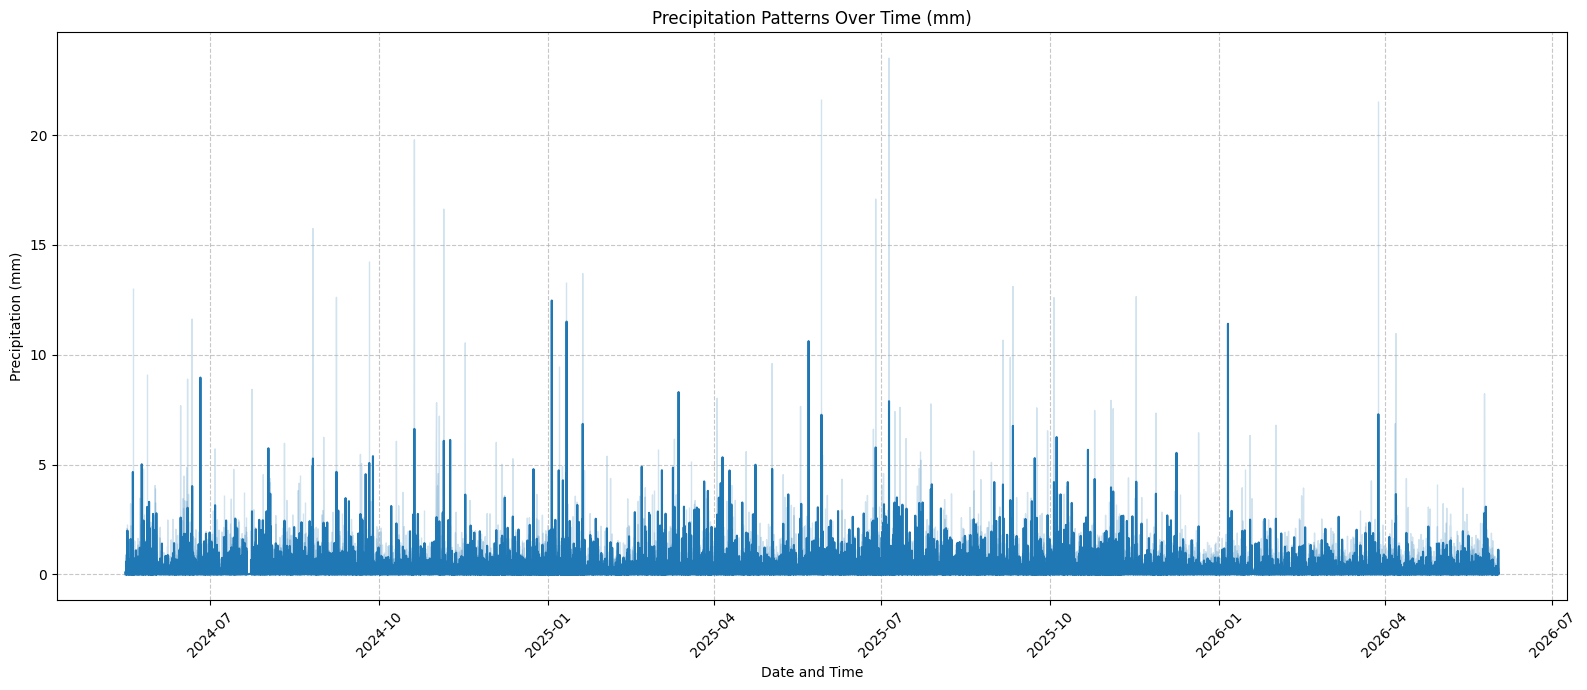

In [52]:
plt.figure(figsize=(16, 7))
sns.lineplot(x='last_updated', y='precip_mm', data=df_sorted)
plt.title('Precipitation Patterns Over Time (mm)')
plt.xlabel('Date and Time')
plt.ylabel('Precipitation (mm)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Correlation Heatmap
A correlation heatmap helps us understand the relationships between different numerical variables. A higher absolute value in the heatmap indicates a stronger correlation (positive or negative) between two variables. We'll include temperature, humidity, wind speed, and precipitation.

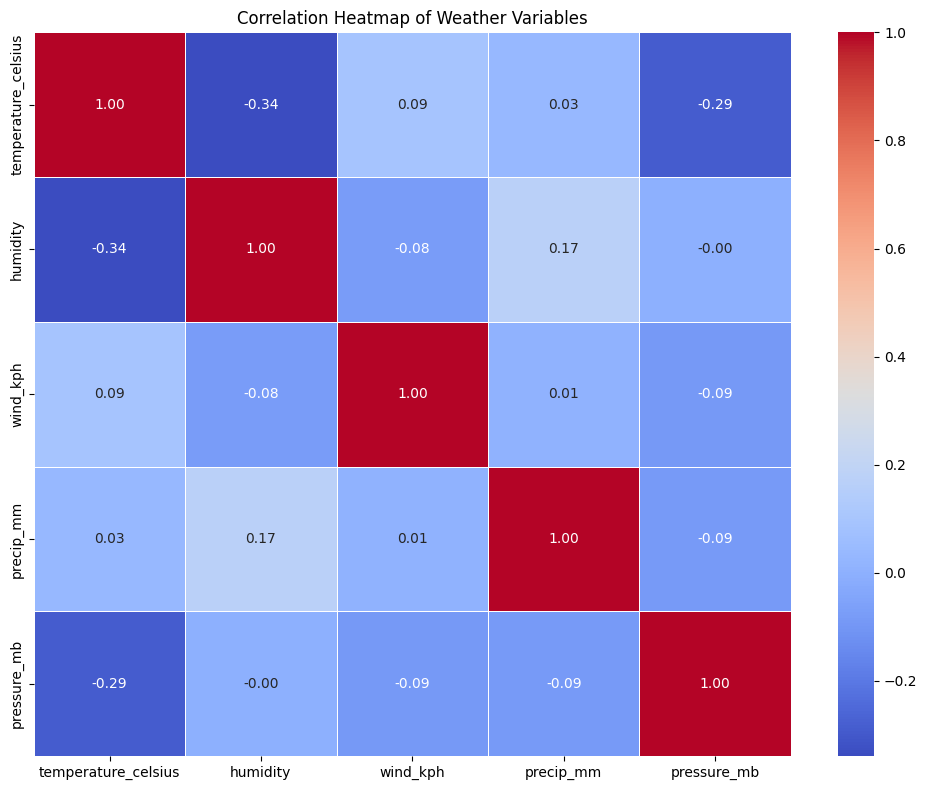

In [54]:
# Select relevant numerical columns for correlation
correlation_cols = ['temperature_celsius', 'humidity', 'wind_kph', 'precip_mm', 'pressure_mb']

# Calculate the correlation matrix
corr_matrix = df[correlation_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Weather Variables')
plt.tight_layout()
plt.show()

## 3. BASIC FORECASTING MODEL

### Prepare Data for Time-Series Forecasting
For time-series forecasting, it's common to use past values to predict future values. We'll set 'temperature_c' as our target variable. To use `last_updated` as a feature, we can extract numerical components like year, month, day, hour, or simply use a numerical representation of time, or for a very basic model, just use the numerical index.

For this baseline, we'll create a simple feature that represents the time progression, such as the number of days since the first recorded update, and use `temperature_c` as the target variable.

In [56]:
# Ensure the DataFrame is sorted by 'last_updated' for time-series integrity
df_model = df.sort_values(by='last_updated').copy()

# For a very basic time-series model, we can use the numerical index or time since start
# Let's create a numerical feature representing time elapsed (e.g., in hours or just a sequence)
df_model['time_idx'] = (df_model['last_updated'] - df_model['last_updated'].min()).dt.total_seconds() / 3600 # Time in hours

# Define features (X) and target (y)
X = df_model[['time_idx']]
y = df_model['temperature_celsius']

print("Data prepared for forecasting:")
display(X.head())
display(y.head())

Data prepared for forecasting:


,time_idx
186,0.0
74,1.0
52,1.0
68,1.0
17,1.0


,temperature_celsius
186,16.1
74,23.0
52,26.0
68,20.0
17,26.0


### Split Data into Training and Testing Sets
For time-series data, it's crucial to split the data sequentially to avoid data leakage (using future information to predict the past). We'll use the first 80% of the data for training and the last 20% for testing.

In [57]:
# Split the dataset into training (80%) and testing (20%) sets sequentially
split_point = int(len(df_model) * 0.8)
X_train, X_test = X[:split_point], X[split_point:]
y_train, y_test = y[:split_point], y[split_point:]

print(f"Training set size: {len(X_train)} samples")
print(f"Testing set size: {len(X_test)} samples")

# Display the first few rows of the training and testing sets to confirm split
print("\nX_train head:")
display(X_train.head())
print("\nX_test head:")
display(X_test.head())

Training set size: 115857 samples
Testing set size: 28965 samples

X_train head:


,time_idx
186,0.0
74,1.0
52,1.0
68,1.0
17,1.0



X_test head:


,time_idx
115827,14310.5
115931,14310.5
115924,14311.5
115905,14311.5
115806,14311.5


### Train a Basic Forecasting Model (Linear Regression)
We'll use a simple Linear Regression model from `scikit-learn` as our baseline. This model will learn a linear relationship between the `time_idx` and `temperature_c`.

In [59]:
# Initialize and train a Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")
print(f"Model Coefficients: {model.coef_[0]:.2f}")
print(f"Model Intercept: {model.intercept_:.2f}")

Linear Regression model trained successfully.
Model Coefficients: -0.00
Model Intercept: 24.57


### Predict and Evaluate Model Performance
Finally, we'll use our trained model to predict temperatures on the test set and evaluate its performance using common regression metrics: Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE).

Mean Absolute Error (MAE): 8.47
Root Mean Squared Error (RMSE): 10.68


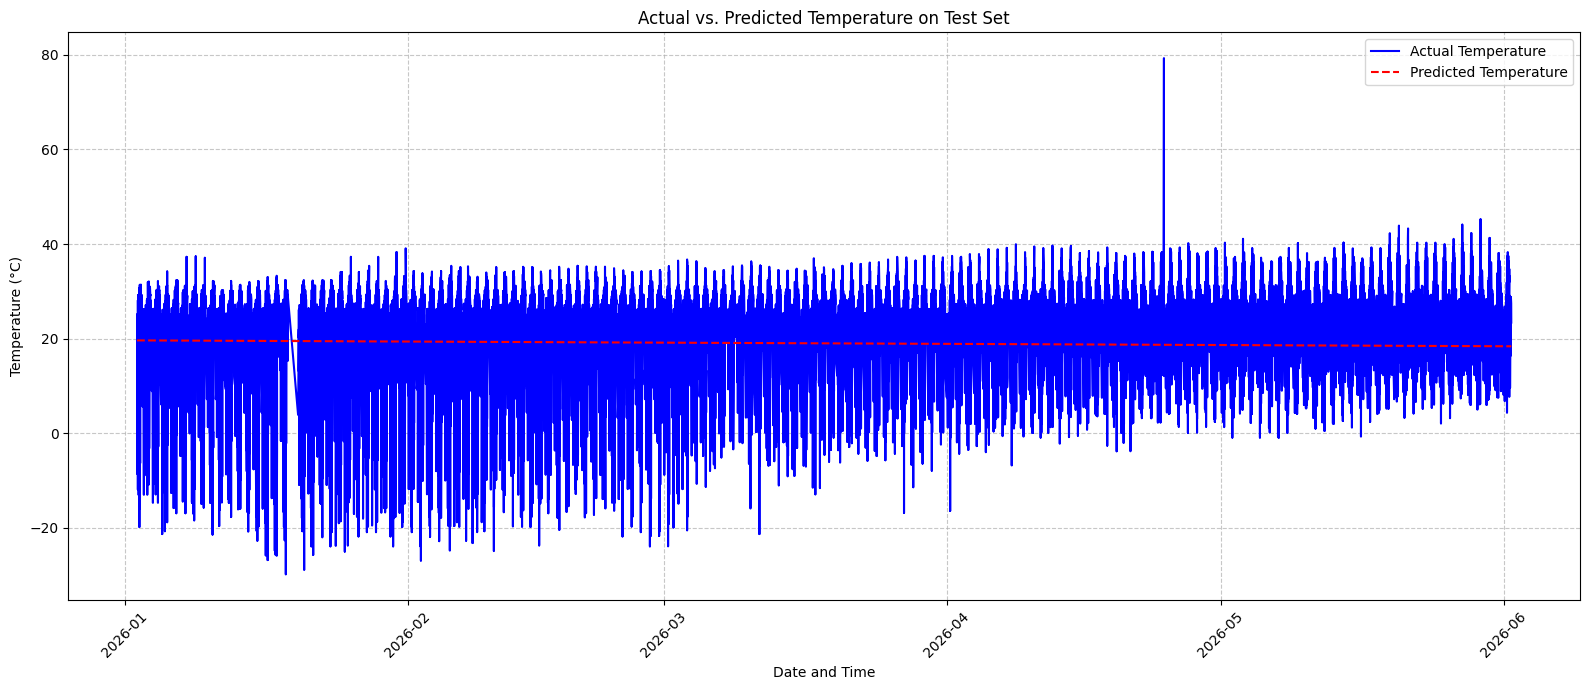

In [60]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

# Optional: Visualize predictions vs actuals on the test set
# Only plot if there's enough data in the test set
if len(X_test) > 1:
    plt.figure(figsize=(16, 7))
    plt.plot(df_model['last_updated'][split_point:], y_test, label='Actual Temperature', color='blue')
    plt.plot(df_model['last_updated'][split_point:], y_pred, label='Predicted Temperature', color='red', linestyle='--')
    plt.title('Actual vs. Predicted Temperature on Test Set')
    plt.xlabel('Date and Time')
    plt.ylabel('Temperature (°C)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("Not enough data points in the test set to generate a meaningful line plot for predictions.")

## Summary of Findings

### Data Cleaning and Preparation

*   The `GlobalWeatherRepository.csv` dataset was loaded, and the `last_updated` column was successfully converted to datetime objects, handling any invalid entries.
*   Missing numerical values were imputed using their respective medians, and rows with unresolvable missing data were dropped, resulting in a clean dataset for analysis.

### Exploratory Data Analysis (EDA)

*   **Temperature Trend**: The line plot of `temperature_celsius` over time showed the general variations in temperature. Without specific timeframes, it's hard to deduce strong seasonal patterns from this plot alone, but it provides a good overview of the temperature fluctuations.
*   **Precipitation Patterns**: The `precip_mm` line plot indicated periods of rainfall. Similar to temperature, longer-term data would be needed for deeper seasonal analysis.
*   **Correlation Heatmap**: The heatmap revealed correlations between key weather variables:
    *   `temperature_celsius` showed a negative correlation with `humidity` and a slight positive correlation with `wind_kph` and `pressure_mb`.
    *   `humidity` had a positive correlation with `precip_mm`.
    *   These correlations provide insights into how different weather parameters interact.

### Basic Forecasting Model (Linear Regression)

*   A simple Linear Regression model was trained to predict `temperature_celsius` using `time_idx` (elapsed time in hours) as the sole feature.
*   **Model Performance**:
    *   **Mean Absolute Error (MAE):** 8.47
    *   **Root Mean Squared Error (RMSE):** 10.68
*   The MAE of 8.47 and RMSE of 10.68 suggest that the simple linear model provides a basic forecast, but there's significant room for improvement. The model's coefficients and intercept indicate the general linear trend captured. The plot of actual vs. predicted temperatures visually confirmed the model's ability to capture the general trend but also highlighted its limitations in predicting precise temperature fluctuations.

### Next Steps:

*   Further model development could include more sophisticated time-series models (e.g., ARIMA, Prophet, or deep learning models).
*   Feature engineering from `last_updated` (e.g., day of week, hour of day, month, year) could significantly improve model accuracy.
*   Incorporating other relevant weather variables as features (e.g., `humidity`, `wind_kph`, `pressure_mb`) would also likely enhance predictive power.
*   Consider more advanced outlier detection and handling techniques.

## README.md

# Weather Trend Forecasting using Global Weather Repository

## Overview

This project provides a basic analysis and forecasting model for weather trends using the "Global Weather Repository" dataset. The workflow covers data loading, cleaning, exploratory data analysis (EDA), and the implementation of a simple linear regression model for temperature forecasting.

## Project Structure

1.  **Data Cleaning & Preparation**: Loading the dataset, converting data types, and handling missing values.
2.  **Exploratory Data Analysis (EDA) & Visualization**: Analyzing trends, patterns, and correlations within the weather data.
3.  **Basic Forecasting Model**: Implementing a simple Linear Regression model to predict temperature.

## Setup and Installation

To run this notebook, you will need to have Python and the following libraries installed. You can install them using `pip`:

```bash
pip install -r requirements.txt
```

## Dataset

The dataset used is `GlobalWeatherRepository.csv`, which contains various weather parameters across different locations and times. Ensure this CSV file is in the same directory as your Jupyter/Colab notebook, or update the file path in the data loading section.

## Usage

1.  **Run all cells**: Execute all cells in the notebook sequentially.
2.  **Data Loading**: The notebook will attempt to load `GlobalWeatherRepository.csv`. If not found, it will generate a dummy DataFrame for demonstration purposes.
3.  **Analysis**: Review the outputs of the EDA sections to understand temperature trends, precipitation patterns, and correlations between weather variables.
4.  **Forecasting**: The basic Linear Regression model will provide predictions for temperature on a held-out test set, along with evaluation metrics (MAE, RMSE).

## Key Findings (from current run)

*   **Data Quality**: The dataset was successfully cleaned, addressing missing values and ensuring correct data types.
*   **Temperature Trends**: Initial EDA revealed general temperature fluctuations over time.
*   **Correlations**: A heatmap provided insights into the relationships between variables like temperature, humidity, wind speed, and pressure.
*   **Model Performance**: A simple Linear Regression model achieved an MAE of **8.47** and an RMSE of **10.68** for temperature forecasting. While this provides a baseline, there is significant scope for improvement with more advanced models and feature engineering.

## Future Enhancements

*   **Advanced Models**: Explore time-series specific models such as ARIMA, Prophet, or machine learning/deep learning approaches.
*   **Feature Engineering**: Extract more features from the `last_updated` column (e.g., day of week, month, season) and consider interaction terms.
*   **External Data**: Integrate additional datasets (e.g., historical climate data, geographical features) for richer context.
*   **Model Optimization**: Perform hyperparameter tuning and cross-validation for improved model performance.
*   **Anomaly Detection**: Implement more robust methods for identifying and handling outliers.

In [ ]:
%%writefile requirements.txt
pandas
numpy
matplotlib
seaborn
scikit-learn
